In [1]:
#Here the knn value is also 1 which is not the default value.

In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from search.parallel_gradient import ParallelGradientDescent
from utils.sampling import BatchNegativeSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "tu_berlin"
default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]

In [3]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)
dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [4]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [5]:
batch_size = next(iter(train_loader))[0].shape[0]


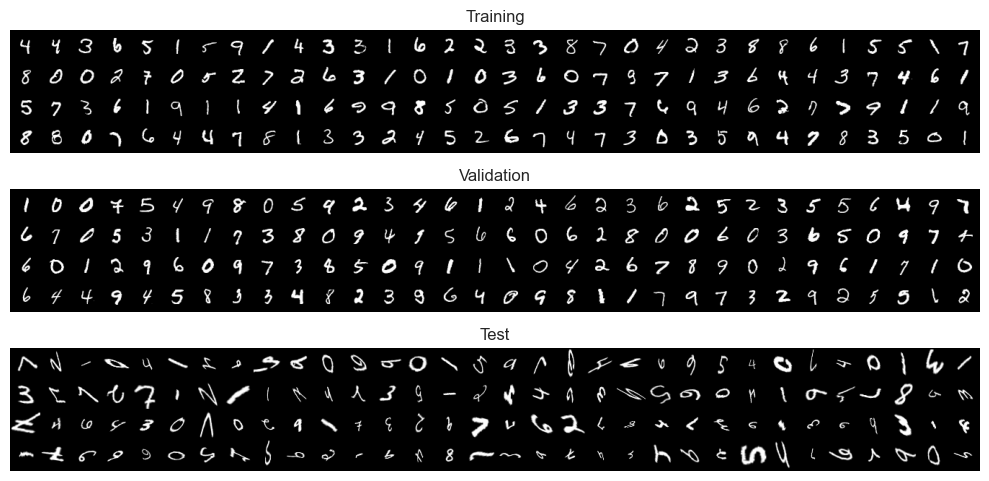

In [6]:
from utils.eval.vis import vis_dataset, plt_setup_latex

vis_dataset(train_loader,val_loader,test_loader_transformed)

In [7]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparision_early_stopping_shared")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

In [8]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [9]:
model.eval().cuda()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [10]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic
make_deterministic(model)


In [11]:
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)

{'accuracy': 0.37689998745918274, 'f2_macro': 0.37094762921333313, 'f2_micro': 0.37689998745918274, 'f2_weighted': 0.3730011582374573}


In [12]:
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.9955999851226807, 'f2_macro': 0.9955340027809143, 'f2_micro': 0.9955999851226807, 'f2_weighted': 0.9955984354019165}


In [13]:
class TensorGeometricModelUnwrapper(torch.nn.Module):
    """
    Wrapper for a torch_geometric model that receives a tuple of (pos, y) as input and creates
    a Data object from it that is passed to the model.
    """
    def __init__(self):
        super(TensorGeometricModelUnwrapper, self).__init__()

    def forward(self, data):
        # pos and y are batched tensors from a DataLoader
        # need to reconstruct the original Data objects for torch_geometric models

        pos = data.pos
        batch = data.batch
        #split pos into individual tensors based on batch
        pos_list = torch.split(pos, torch.bincount(batch).tolist())
        return torch.stack(pos_list)

In [14]:
#chek if data is iamge data
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

In [15]:
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    ).cuda()

In [16]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 0, num_classes=None, num_rotations=8)

In [17]:
from confidence.direct.logit_based import EnergyConfidence
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence

logit_energy = SinglePassConfidence(model, EnergyConfidence(), index=None)
problem_energy_logits = TransformationProblem(logit_energy, transform_seq,                                              consolidate_method="consolidate_simple")
#test ot
from search.shgo import SHGO
random_search = SHGO(initial_samples=120, local_max_steps=0)

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search,evaluate_confidence_and_search


In [18]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.8080000281333923,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.8036046028137207,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.8080000281333923,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.8052770495414734,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.8080000281333923,
   'f2_macro': 0.8036046028137207,
   'f2_micro': 0.8080000281333923,
   'f2_weighted': 0.8052770495414734,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [19]:
model.cuda().eval()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [20]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [21]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = utils.augments.build_default_augmentations()
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)

energy_conf2 = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy2", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_energy_conf_best.safetensors
Model has non-negative constraint: False


In [22]:
model.cuda().eval()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [23]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic

make_deterministic(model)

In [24]:
energy_conf2.cuda().eval()
problem_energy2 = TransformationProblem(energy_conf2, transform_seq,                                              consolidate_method="consolidate_simple")



In [25]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy2,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.9739999771118164,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9738460779190063,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9739999771118164,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.9739716053009033,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9739999771118164,
   'f2_macro': 0.9738460779190063,
   'f2_micro': 0.9739999771118164,
   'f2_weighted': 0.9739716053009033,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [26]:
set_deterministic_fps(energy_conf2)

In [27]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [28]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache



cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))

dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True)
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=layer_io, flatten=True)




from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None,computation_mode="triton",k=1)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")
model.eval().cuda()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [29]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed"), show_progress=True,
    repeats=1,overwrite=False)

{'repeats': 1,
 'accuracy_mean': 0.8751000165939331,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.8733792901039124,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.8751000165939331,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.8745673298835754,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.8751000165939331,
   'f2_macro': 0.8733792901039124,
   'f2_micro': 0.8751000165939331,
   'f2_weighted': 0.8745673298835754,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [30]:
gc.collect()
torch.cuda.empty_cache()

In [31]:
#test wether model is deterministic

In [32]:
make_deterministic(model)
make_deterministic(energy_conf2)

In [33]:
x = next(iter(train_loader_no_shuffle))

In [34]:
res1= dual_output_model(x[0].to(device))[0].cpu().detach().numpy()

In [35]:
res2 = embeddings_t[:x[0].shape[0]].cpu().detach().numpy()


In [36]:
res1

array([[ 0.2860472 , -0.13343544,  0.651979  , ...,  0.00417738,
         1.1631814 ,  0.4306842 ],
       [ 0.09417275, -0.10633662, -0.13433842, ..., -0.07910456,
        -0.16172944, -0.1346775 ],
       [ 0.55100757, -0.06990977,  0.1541654 , ...,  0.18716924,
         1.2036424 ,  0.5368439 ],
       ...,
       [ 0.47213063, -0.10111753, -0.13435544, ..., -0.03285865,
        -0.09606729, -0.13098441],
       [ 0.20995855,  1.5063953 , -0.13684162, ...,  0.06880064,
        -0.13279167, -0.11963227],
       [-0.0840968 , -0.1303982 , -0.13769841, ..., -0.10826414,
        -0.13969214,  0.08433399]], shape=(128, 512), dtype=float32)

In [37]:
if not np.allclose(res1, res2,atol=1e-5, rtol=1e-5):
    raise ValueError("Model is not deterministic!")
else:
    print("Model is deterministic.")

Model is deterministic.


In [38]:
from tqdm import tqdm
import numpy as np
import torch
from typing import Dict

def confidence_percentiles_from_dataloader_pc(
    problem: "TransformationProblem",
    dataloader: "torch.utils.data.DataLoader",
    device: torch.device,
    percentile: int = 95,
        additional_classifer: torch.nn.Module = None,
) -> Dict[int, Dict[str, any]]:
    """
    Compute per-class confidence percentiles using the problem's error function,
    with zero parameters, but only for correctly classified samples.

    Args:
        problem: the TransformationProblem instance (must have confidence_module(x)).
        dataloader: yields batches of (x, y).
        device: torch device to put tensors on.

    Returns:
        Dict[label, {"count": int, "percentile": float}]
    """
    all_conf = []
    all_labels = []

    for batch in tqdm(dataloader, desc="Computing confidence percentiles"):
        x, y = batch
        x, y = x.to(device), y.to(device)

        errors, logits = problem.confidence_module(x)
        if logits is None:
            logits = additional_classifer(x)
        if errors.ndim > 1:
            errors = errors.mean(dim=-1)

        conf = errors.detach().cpu().numpy()  # confidence = -error
        preds = torch.argmax(logits, dim=-1)

        mask = preds.eq(y)  # only keep correct predictions

        if mask.any():
            all_conf.append(conf[mask.cpu().numpy()])
            all_labels.append(y[mask].detach().cpu().numpy())

    if not all_conf:  # in case no correct predictions
        return {}

    all_conf = np.concatenate(all_conf)
    all_labels = np.concatenate(all_labels)

    out: Dict[int, Dict[str, any]] = {}
    for c in np.unique(all_labels):
        mask = all_labels == c
        if not mask.any():
            continue
        vals = all_conf[mask]
        out[c] = {
            "count": int(mask.sum()),
            "percentile": float(np.percentile(vals, percentile)),
        }

    # return list of percentiles sorted by class
    return [out[c]["percentile"] for c in sorted(out.keys())]

def confidence_percentiles_from_dataloader(
    problem: "TransformationProblem",
    dataloader: "torch.utils.data.DataLoader",
    device: torch.device,
    percentile: int = 95,
    additional_classifer: torch.nn.Module = None,
) -> float:
    """
    Compute a shared confidence percentile across all correctly classified samples.

    Args:
        problem: The TransformationProblem instance (must have confidence_module(x)).
        dataloader: yields batches of (x, y).
        device: torch device to put tensors on.
        percentile: desired percentile to compute.
        additional_classifier: optional classifier if problem.confidence_module does not return logits.

    Returns:
        Single float: the requested confidence percentile.
    """
    all_conf = []

    for batch in tqdm(dataloader, desc="Computing confidence percentiles"):
        x, y = batch
        x, y = x.to(device), y.to(device)

        errors, logits = problem.confidence_module(x)
        if logits is None and additional_classifer is not None:
            logits = additional_classifer(x)
        if errors.ndim > 1:
            errors = errors.mean(dim=-1)

        conf = errors.detach().cpu().numpy()  # confidence = -error
        preds = torch.argmax(logits, dim=-1)

        mask = preds.eq(y)  # only keep correct predictions
        if mask.any():
            all_conf.append(conf[mask.cpu().numpy()])

    if not all_conf:  # in case no correct predictions
        return float("nan")

    all_conf = np.concatenate(all_conf)
    return float(np.percentile(all_conf, percentile))


In [39]:
pytorch_nn_threshold = confidence_percentiles_from_dataloader(
    problem_nn_pytorch_pretrained, train_loader_transformed, device, percentile=75)

Computing confidence percentiles: 100%|██████████| 422/422 [00:16<00:00, 25.52it/s]


In [40]:
energy_threshold = confidence_percentiles_from_dataloader(
    problem_energy_logits, train_loader_transformed, device, percentile=75)



Computing confidence percentiles: 100%|██████████| 422/422 [00:03<00:00, 136.40it/s]


In [41]:
energy_learned_threshold = confidence_percentiles_from_dataloader(
    problem_energy2, train_loader_transformed, device, percentile=75,additional_classifer=model)

Computing confidence percentiles: 100%|██████████| 422/422 [00:05<00:00, 81.88it/s]


In [42]:
import torch
from typing import List, Any, Optional, Tuple, Dict

class AdaptiveBatchMetaOptimizer:
    """
    Streams a large dataset through internal optimizers using a limited working batch.
    Tracks per-sample cycles and stops when confidence threshold or max_cycles is reached.
    """

    def __init__(
        self,
        internal_optimizers: List[Any],
        internal_batch_size: int = 128,
        confidence_threshold: float = 0.9,
        max_cycles: int = 1000,          # per-sample max optimizer calls
        device: Optional[torch.device] = None,
        retain_history: bool = False,
        global_call_cap: Optional[int] = None  # optional safety cap over ALL calls
    ):
        self.internal_optimizers = internal_optimizers
        self.internal_batch_size = internal_batch_size
        if isinstance(confidence_threshold, (float, int)):
            self.confidence_threshold = torch.tensor([confidence_threshold])
        else:
            self.confidence_threshold = torch.tensor(confidence_threshold, dtype=torch.float32)
        self.max_cycles = max_cycles
        self.device = device
        self.retain_history = retain_history
        self.global_call_cap = global_call_cap

        # Internal cumulative history
        if retain_history:
            self._history: Dict[str, list] = {
                "n_samples": [],
                "percentage_max_calls": []
            }
        else:
            self._history = None

    @staticmethod
    def _compute_confidence(error: torch.Tensor) -> torch.Tensor:
        return -error

    def _refill_active(self, active: torch.Tensor, queue: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        need = self.internal_batch_size - active.numel()
        if need > 0 and queue.numel() > 0:
            take = queue[:need]
            queue = queue[need:]
            if active.numel() == 0:
                return take, queue
            active = torch.cat([active, take], dim=0)
        return active, queue

    def optimize(
        self,
        problem: Any,
        x: torch.Tensor,
        y: Optional[torch.Tensor] = None,
        verbose: bool = False
    ) -> Tuple[torch.Tensor, torch.Tensor, Optional[torch.Tensor]]:
        device = self.device or x.device
        x = x.to(device)
        if y is not None:
            y = y.to(device)

        N = x.shape[0]
        best_param: Optional[torch.Tensor] = None
        best_error = torch.full((N,), float("inf"), device=device)
        best_other: Optional[torch.Tensor] = None  # stores logits / "other" info

        indices = torch.arange(N, device=device)
        active = indices[: self.internal_batch_size]
        queue = indices[self.internal_batch_size:]

        # Cycles per sample, same size as total data
        cycles = torch.zeros(N, dtype=torch.int32, device=device)

        dim_placeholder = None
        outer_pass = 0

        threshold_tensor = self.confidence_threshold.to(device)

        while active.numel() > 0:
            outer_pass += 1
            if verbose:
                print(f"[Pass {outer_pass}] Active={active.numel()} Queue={queue.numel()} "
                      f"Remaining={active.numel()+queue.numel()}")
                print(f"Active indices: {active.tolist()}")

            for opt in self.internal_optimizers:
                if active.numel() == 0:
                    break
                if self.global_call_cap is not None and cycles.sum().item() >= self.global_call_cap:
                    if verbose:
                        print("Global call cap reached.")
                    break

                # Drop over-budget samples
                over_budget_mask = cycles[active] >= self.max_cycles
                if over_budget_mask.any():
                    active = active[~over_budget_mask]
                    active, queue = self._refill_active(active, queue)
                    if active.numel() == 0:
                        break

                x_act = x[active]
                y_act = y[active] if y is not None else None

                seed_params = None
                if best_param is not None:
                    seed_params = best_param[active].clone()
                    invalid = best_error[active].isinf()
                    if invalid.any():
                        seed_params[invalid] = 0.0

                opt_kwargs = {}
                if seed_params is not None and "initial_params" in opt.optimize.__code__.co_varnames:
                    opt_kwargs["initial_params"] = seed_params

                # Pass y if available
                if y_act is not None:
                    result = opt.optimize(problem, x_act, y=y_act, verbose=False, **opt_kwargs)
                else:
                    result = opt.optimize(problem, x_act, verbose=False, **opt_kwargs)

                if not (isinstance(result, (tuple, list)) and len(result) == 3):
                    raise RuntimeError("Internal optimizer must return (param, error, other).")

                p_new, e_new, o_new = result

                if dim_placeholder is None:
                    dim_placeholder = p_new.shape[-1]
                    best_param = torch.zeros((N, dim_placeholder), device=device, dtype=p_new.dtype)
                if (o_new is not None) and (best_other is None):
                    best_other = torch.zeros((N, o_new.shape[-1]), device=device, dtype=o_new.dtype)

                improved = e_new < best_error[active]
                if improved.any():
                    best_param[active[improved]] = p_new[improved]
                    best_error[active[improved]] = e_new[improved]
                    if best_other is not None and o_new is not None:
                        best_other[active[improved]] = o_new[improved]

                # Increment cycles for active batch
                cycles[active] += 1

                conf_active = self._compute_confidence(best_error[active])

                # Per-class threshold using predicted class from best_other
                if threshold_tensor.numel() == 1 or best_other is None:
                    done_conf_mask = conf_active >= threshold_tensor.item()
                else:
                    pred_class = best_other[active].argmax(dim=-1)
                    done_conf_mask = conf_active >= threshold_tensor[pred_class]

                done_budget_mask = cycles[active] >= self.max_cycles
                done_mask = done_conf_mask | done_budget_mask

                if done_mask.any():
                    keep = active[~done_mask]
                    active = keep
                    active, queue = self._refill_active(active, queue)

                if (active.numel() == 0 and queue.numel() == 0) or \
                   (self.global_call_cap is not None and cycles.sum().item() >= self.global_call_cap):
                    break

                # Force refill if all active exhausted budget
                if active.numel() > 0 and (cycles[active] >= self.max_cycles).all():
                    empty = active.new_empty(0)
                    active, queue = self._refill_active(empty, queue)

        # --- Update cumulative history once per optimize() call ---
        if self.retain_history:
            n_samples = N
            percentage_used = (cycles.float() / self.max_cycles).mean().item() * 100
            self._history["n_samples"].append(n_samples)
            self._history["percentage_max_calls"].append(percentage_used)

        return best_param, best_error, best_other


    def get_and_reset_history(self) -> Optional[Tuple[Dict[str, list], float]]:
        """
        Returns the cumulative history and resets it for new runs.
        Returns a tuple:
          - hist_copy: the raw lists of n_samples and percentage_max_calls
          - weighted_avg: weighted average of percentage_max_calls over all samples
        """
        if not self.retain_history:
            return None

        hist_copy = {k: v.copy() for k, v in self._history.items()}

        if len(hist_copy["n_samples"]) > 0:
            weighted_avg = np.average(
                hist_copy["percentage_max_calls"],
                weights=hist_copy["n_samples"]
            )
        else:
            weighted_avg = 0.0

        # reset history
        self._history = {k: [] for k in self._history.keys()}

        return hist_copy, weighted_avg


In [43]:
import search



di_small = search.shgo.SHGO(selection_method="topk", initial_samples=20, local_runs=1, local_max_steps=0)
adaptive_shgo_knn = AdaptiveBatchMetaOptimizer(internal_optimizers=[di_small], internal_batch_size=dataset_info.batch_size_search,
                                           max_cycles=6, confidence_threshold=pytorch_nn_threshold,retain_history=True, device=device
                                           )
adaptive_shgo_energy = AdaptiveBatchMetaOptimizer(internal_optimizers=[di_small], internal_batch_size=dataset_info.batch_size_search,
                                           max_cycles=6, confidence_threshold=energy_threshold,retain_history=True, device=device
                                           )
adaptive_shgo_learned_energy = AdaptiveBatchMetaOptimizer(internal_optimizers=[di_small], internal_batch_size=dataset_info.batch_size_search,
                                           max_cycles=6, confidence_threshold=energy_learned_threshold,retain_history=True, device=device)

total_samples = di_small.initial_samples*adaptive_shgo_knn.max_cycles

In [44]:
larger_loader_test = torch.utils.data.DataLoader(
    test_loader_transformed.dataset,
    batch_size=dataset_info.batch_size_search*8,
    num_workers=test_loader_transformed.num_workers,
    persistent_workers=test_loader_transformed.persistent_workers,shuffle=True
)

In [45]:
import math,json

# === Adaptive SHGO for PyTorch NN ===
res_adaptive_nn = load_or_run_evaluate_confidence_and_search(
    model, optimizer=adaptive_shgo_knn, problem=problem_nn_pytorch_pretrained,
    test_loader=larger_loader_test, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed_adaptive"), show_progress=True,
    repeats=4, overwrite=False
)
hist_nn, avg_nn = adaptive_shgo_knn.get_and_reset_history()

if hist_nn is None or len(hist_nn["n_samples"]) == 0:
    import json
    with open(savepath("knn_per_class_confidence_transformed_adaptive_budget_stats"), "r") as f:
        data = json.load(f)
        hist_nn = data["history"]
        avg_nn = data["average_percentage"]
else:
    with open(savepath("knn_per_class_confidence_transformed_adaptive_budget_stats"), "w") as f:
        json.dump({"history": hist_nn, "average_percentage": avg_nn}, f)

budget_nn = math.ceil(total_samples * avg_nn / 100)
shgo_budget_nn = search.shgo.SHGO(selection_method="topk", initial_samples=budget_nn,
                                  local_runs=1, local_max_steps=0)
res_budget_nn = load_or_run_evaluate_confidence_and_search(
    model, optimizer=shgo_budget_nn, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed_shgo_budget"), show_progress=True,
    repeats=4, overwrite=False
)


# === Adaptive SHGO for Energy ===
res_adaptive_energy = load_or_run_evaluate_confidence_and_search(
    model, optimizer=adaptive_shgo_energy, problem=problem_energy_logits,
    test_loader=larger_loader_test, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_per_class_confidence_transformed_adaptive"), show_progress=True,
    repeats=4, overwrite=False
)
hist_energy, avg_energy = adaptive_shgo_energy.get_and_reset_history()

if hist_energy is None or len(hist_energy["n_samples"]) == 0:
    with open(savepath("energy_per_class_confidence_transformed_adaptive_budget_stats"), "r") as f:
        data = json.load(f)
        hist_energy = data["history"]
        avg_energy = data["average_percentage"]
else:
    with open(savepath("energy_per_class_confidence_transformed_adaptive_budget_stats"), "w") as f:
        json.dump({"history": hist_energy, "average_percentage": avg_energy}, f)

budget_energy = math.ceil(total_samples * avg_energy / 100)
shgo_budget_energy = search.shgo.SHGO(selection_method="topk", initial_samples=budget_energy,
                                      local_runs=1, local_max_steps=0)
res_budget_energy = load_or_run_evaluate_confidence_and_search(
    model, optimizer=shgo_budget_energy, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_per_class_confidence_transformed_shgo_budget"), show_progress=True,
    repeats=4, overwrite=False
)


# === Adaptive SHGO for Learned Energy ===
res_adaptive_learned = load_or_run_evaluate_confidence_and_search(
    model, optimizer=adaptive_shgo_learned_energy, problem=problem_energy2,
    test_loader=larger_loader_test, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_per_class_confidence_transformed_adaptive"), show_progress=True,
    repeats=4, overwrite=False
)
hist_learned, avg_learned = adaptive_shgo_learned_energy.get_and_reset_history()

if hist_learned is None or len(hist_learned["n_samples"]) == 0:
    with open(savepath("learned_energy_per_class_confidence_transformed_adaptive_budget_stats"), "r") as f:
        data = json.load(f)
        hist_learned = data["history"]
        avg_learned = data["average_percentage"]
else:
    with open(savepath("learned_energy_per_class_confidence_transformed_adaptive_budget_stats"), "w") as f:
        json.dump({"history": hist_learned, "average_percentage": avg_learned}, f)

budget_learned = math.ceil(total_samples * avg_learned / 100)
shgo_budget_learned = search.shgo.SHGO(selection_method="topk", initial_samples=budget_learned,
                                       local_runs=1, local_max_steps=0)
res_budget_learned = load_or_run_evaluate_confidence_and_search(
    model, optimizer=shgo_budget_learned, problem=problem_energy2,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_per_class_confidence_transformed_shgo_budget"), show_progress=True,
    repeats=4, overwrite=False
)


In [46]:

figure_path = os.path.join(current_path, "experiment_files", "export", "fig", "comparision_search_adaptive", dataset,
                           transform_name)
W = plt_setup_latex()

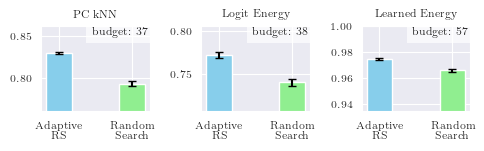

In [47]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['Adaptive\n RS', 'Random\n Search']
x = np.arange(len(labels))
width = 0.35

# Problems already defined earlier in your code
problems = [
    ("PC kNN", res_adaptive_nn, res_budget_nn, budget_nn),
    ("Logit Energy", res_adaptive_energy, res_budget_energy, budget_energy),
    ("Learned Energy", res_adaptive_learned, res_budget_learned, budget_learned)
]

# Compute global y-limits from accuracy means/errors
all_means = []
all_errors = []
for _, res_adaptive, res_budget, _ in problems:
    all_means.extend([res_adaptive["accuracy_mean"], res_budget["accuracy_mean"]])
    all_errors.extend([res_adaptive["accuracy_se"], res_budget["accuracy_se"]])

min_y = max(0, min(all_means) - max(all_errors) - 0.03)
max_y = min(1, max(all_means) + max(all_errors) + 0.03)

fig, axes = plt.subplots(1, 3, figsize=(W, W/3))

for ax, (title, res_adaptive, res_budget, budget) in zip(axes, problems):
    # Ensure budget is a single integer sample count
    try:
        budget_val = int(np.asarray(budget).item())
    except Exception:
        budget_val = int(budget)

    means = [res_adaptive["accuracy_mean"], res_budget["accuracy_mean"]]
    errors = [res_adaptive["accuracy_se"]*1.96, res_budget["accuracy_se"]*1.96]

    # Set y-limits per problem
    min_y = max(0, min(means) - max(errors) - 0.03)
    max_y = min(1, max(means) + max(errors) + 0.03)

    bars = ax.bar(x, means, width, yerr=errors, capsize=3, color=['skyblue', 'lightgreen'])

    # Annotate bars (optional)
    for bar, mean, se in zip(bars, means, errors):
        height = bar.get_height()
        # ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
        #         f"{mean:.3f}±{se:.3f}",
        #         ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Set title and budget label
    ax.set_title(f"{title}", fontweight='bold', fontsize=8)
    ax.text(0.98, 0.98, f"budget: {budget_val}", transform=ax.transAxes,
            ha='right', va='top', fontsize=8, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim([min_y, max_y])  # Use per-problem limits

plt.tight_layout()
os.makedirs(figure_path, exist_ok=True)
plt.savefig(os.path.join(figure_path, "comparision_adaptive_vs_fixed_budget.pdf"), dpi=300)
plt.savefig(os.path.join(figure_path, "comparision_adaptive_vs_fixed_budget.pgf"), dpi=300)
plt.show()


In [48]:
#store budget

In [49]:
import gc
gc.collect()
torch.cuda.empty_cache()